# Series de Tiempo Aplicadas al Mercado Financiero: S&P 500 vs. Dow Jones
# Holt-Winters, ARIMA (rolling) y LSTM

**Curso:** IA Generativa para la Gestión  
**Integrantes:** Tomás Allende – Juan Costa – Felipe Castillo  
**Propuesta:** N° 8 – Series de mercado a elección (Yahoo Finance vía Python)  
**Fecha de descarga de datos:** 16 de septiembre de 2026

---

Este notebook aplica, sobre el índice **S&P 500** (`^GSPC`), los tres enfoques
de modelamiento de series de tiempo trabajados en el módulo:

1. **Suavizamiento exponencial (Holt-Winters)**
2. **ARIMA con pronóstico rolling (walk-forward)**
3. **LSTM (red neuronal recurrente)**

Adicionalmente se descarga el **Dow Jones Industrial Average** (`^DJI`) para
realizar un análisis de **cointegración** entre ambos índices y extraer
conclusiones de gestión.

### Justificación de la elección

- **S&P 500 y Dow Jones** son los dos índices bursátiles más seguidos del mundo,
  ambos de gran capitalización estadounidense.
- Comparten un número importante de empresas (las 30 del Dow Jones están todas
  en el S&P 500), lo que genera una relación de equilibrio de largo plazo
  teóricamente fuerte, ideal para validar el método de cointegración.
- Los datos son públicos, diarios, reales y fácilmente reproducibles vía
  `yfinance`.
- El período elegido (2015–2025) captura ciclos completos: subida 2015-2019,
  crash COVID 2020, recuperación, caída por inflación 2022 y rally 2023-2025.

## Etapa 1 — Selección y justificación de las series

| Campo | Detalle |
|---|---|
| **Tickers** | `^GSPC` (S&P 500) y `^DJI` (Dow Jones Industrial Average) |
| **Fuente** | Yahoo Finance vía la librería `yfinance` de Python |
| **Período** | 2015-01-01 a 2025-09-16 (~10,7 años de datos diarios) |
| **Columna utilizada** | `Close` (precio de cierre) |
| **Frecuencia** | Diaria (días hábiles bursátiles, ~252 por año) |
| **Fecha de descarga** | 16 de septiembre de 2026 |

**¿Por qué este par?** Ambos índices representan la renta variable de gran
capitalización en EE.UU. Las 30 empresas del Dow Jones están incluidas en el
S&P 500, por lo que existe una relación teórica de equilibrio de largo plazo.
Esto los convierte en un caso clásico para validar que el procedimiento de
cointegración distingue correctamente una relación de equilibrio real.

## 1. Instalación de librerías e importaciones

In [1]:
!pip install yfinance pmdarima statsmodels scikit-learn tensorflow

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import yfinance as yf

import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, coint

from statsmodels.tsa.holtwinters import ExponentialSmoothing

import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler

np.random.seed(2026)
tf.random.set_seed(2026)

## 2. Carga de datos desde Yahoo Finance

In [3]:
# Descargar ambos indices
data = yf.download(["^GSPC", "^DJI"], start="2015-09-16", end="2025-09-16")

# Extraer precio de cierre
df = data["Close"].dropna()
df.columns = ["DJI", "SP500"]
df.index.name = "Fecha"

print(f"Rango de fechas: {df.index.min().date()} a {df.index.max().date()}")
print(f"Total de observaciones: {len(df)}")
df.head()

[*********************100%***********************]  2 of 2 completed

Rango de fechas: 2015-09-16 a 2025-09-15
Total de observaciones: 2514


,DJI,SP500
Fecha,,
2015-09-16,16739.949219,1995.310059
2015-09-17,16674.740234,1990.199951
2015-09-18,16384.580078,1958.030029
2015-09-21,16510.189453,1966.969971
2015-09-22,16330.469727,1942.739990


In [4]:
# Serie principal para modelar
sp500 = df[["SP500"]].copy()
sp500.head()

,SP500
Fecha,
2015-09-16,1995.310059
2015-09-17,1990.199951
2015-09-18,1958.030029
2015-09-21,1966.969971
2015-09-22,1942.739990


## Etapa 2 — Análisis exploratorio y cointegración

### 2.1 Visualización de ambas series

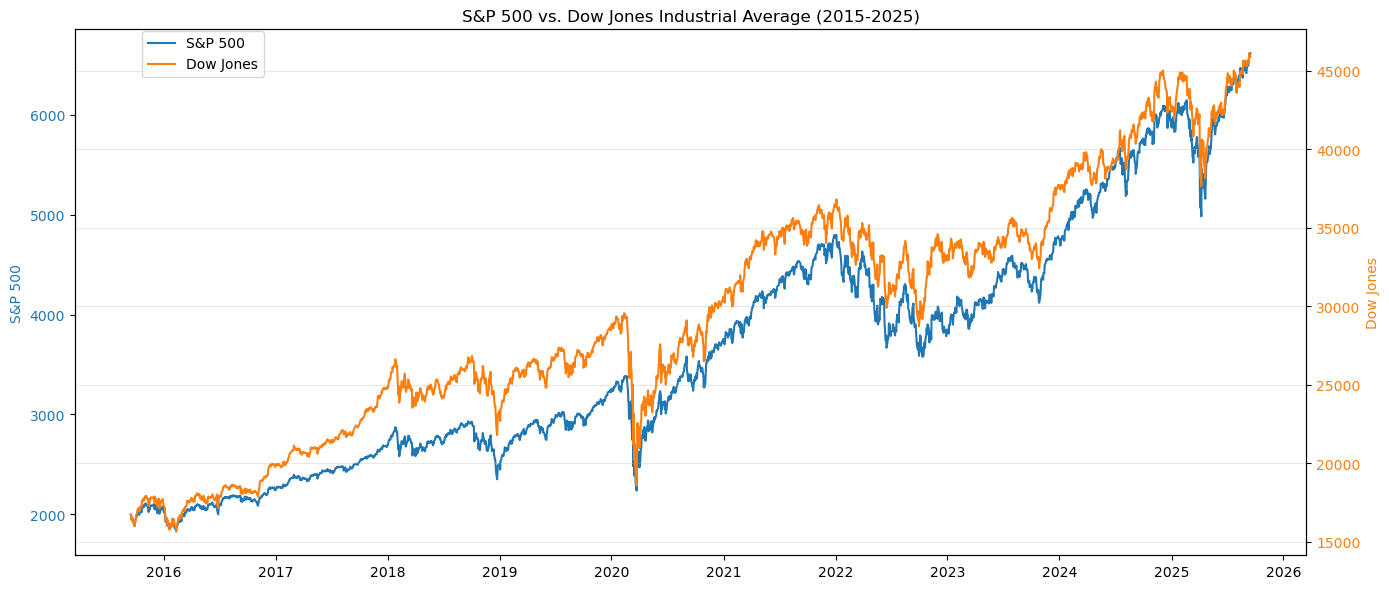

In [5]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df.index, df["SP500"], label="S&P 500", color="tab:blue")
ax1.set_ylabel("S&P 500", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(df.index, df["DJI"], label="Dow Jones", color="tab:orange")
ax2.set_ylabel("Dow Jones", color="tab:orange")
ax2.tick_params(axis='y', labelcolor="tab:orange")

plt.title("S&P 500 vs. Dow Jones Industrial Average (2015-2025)")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.95))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Estadísticas descriptivas

In [6]:
df.describe().round(2)

,DJI,SP500
count,2514.00,2514.00
mean,29469.71,3629.54
std,7739.49,1214.19
min,15660.18,1829.08
25%,24041.42,2645.41
50%,28585.29,3380.26
75%,34702.92,4436.69
max,46108.00,6615.28


### 2.3 Test de estacionariedad (ADF) sobre cada serie

In [7]:
for col in ["SP500", "DJI"]:
    adf_test = adfuller(df[col])
    print(f"--- {col} ---")
    print(f"ADF Statistic: {adf_test[0]:.4f}")
    print(f"p-value: {adf_test[1]:.6f}")
    if adf_test[1] <= 0.05:
        print("=> La serie ES estacionaria")
    else:
        print("=> La serie NO es estacionaria")
    print()

--- SP500 ---
ADF Statistic: 0.4547
p-value: 0.983429
=> La serie NO es estacionaria

--- DJI ---
ADF Statistic: -0.5979
p-value: 0.871453
=> La serie NO es estacionaria



Interpretacion: Una serie es estacionaria cuando su media y varianza se mantienen constantes en un determinado plazo. En este caso, netamente viendo el gráfico se puede ver que ni una de las dos lo son. 
(ADF no rechaza $H_0$), lo cual
es esperable en precios bursátiles: siguen una tendencia alcista de largo plazo.
Esto justifica la necesidad de diferenciar antes de aplicar ARIMA, y también
hace relevante el análisis de cointegración (dos series I(1) pueden estar
cointegradas si existe una combinación lineal estacionaria entre ellas).

### 2.4 Correlación entre las series

Correlación de Pearson entre S&P 500 y Dow Jones: 0.9881


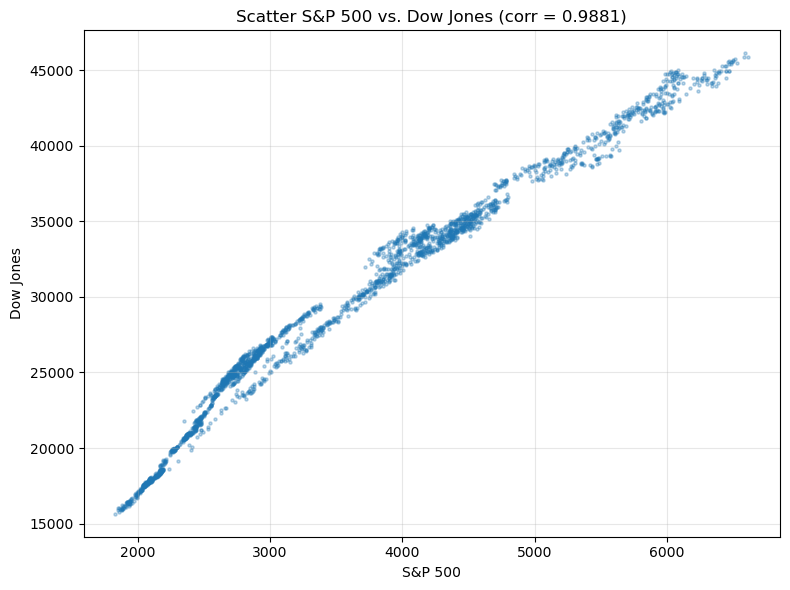

In [8]:
corr = df["SP500"].corr(df["DJI"])
print(f"Correlación de Pearson entre S&P 500 y Dow Jones: {corr:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(df["SP500"], df["DJI"], alpha=0.3, s=5)
plt.xlabel("S&P 500")
plt.ylabel("Dow Jones")
plt.title(f"Scatter S&P 500 vs. Dow Jones (corr = {corr:.4f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.5 Test de cointegración de Engle-Granger

In [9]:
# Test de cointegracion de Engle-Granger (dos series)
score, pvalue, _ = coint(df["SP500"], df["DJI"])
print(f"Estadístico de cointegración: {score:.4f}")
print(f"p-value: {pvalue:.6f}")

if pvalue <= 0.05:
    print("=> Las series ESTÁN cointegradas (se rechaza H0 de no cointegración)")
else:
    print("=> Las series NO están cointegradas (no se rechaza H0)")

Estadístico de cointegración: -2.2636
p-value: 0.391870
=> Las series NO están cointegradas (no se rechaza H0)


### 2.6 Interpretación de la cointegración

Si hay cointegración: existe una relación de equilibrio de largo plazo entre
el S&P 500 y el Dow Jones. Cuando una se desvía de la otra, tienden a
reconvergir. Esto tiene implicancias prácticas:
- Una serie puede servir como indicador líder de la otra.
- Se pueden diseñar estrategias de pairs trading o cobertura (hedging)*
  si el spread se abre más de lo normal, se apuesta a que volverá.

Si no hay cointegración: aunque las series estén altamente correlacionadas,
no existe una relación de equilibrio estable. La correlación alta puede ser
espuria (ambas suben por factores comunes pero no se "atraen" mutuamente).
Esto significa que las desviaciones entre ellas pueden persistir y no corregirse,
lo cual es un hallazgo relevante para la gestión de riesgos.

### 2.7 Descomposición de la serie S&P 500

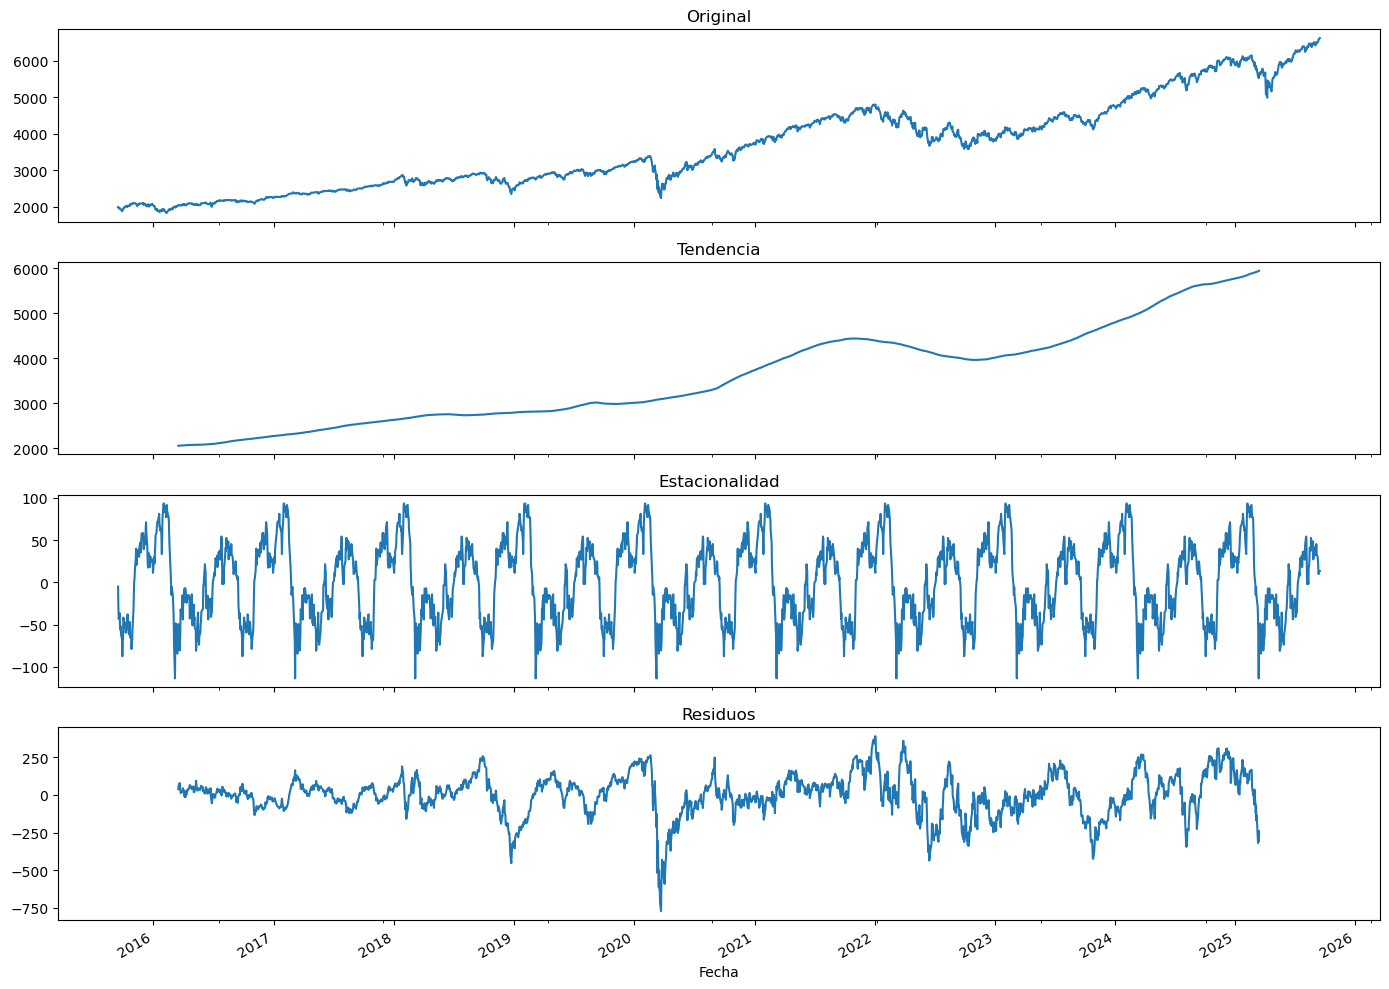

In [10]:
# Descomposicion aditiva con periodo anual (~252 dias habiles)
decomp = seasonal_decompose(sp500["SP500"], model='additive', period=252)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title="Original")
decomp.trend.plot(ax=axes[1], title="Tendencia")
decomp.seasonal.plot(ax=axes[2], title="Estacionalidad")
decomp.resid.plot(ax=axes[3], title="Residuos")
plt.tight_layout()
plt.show()

El S&P 500 muestra una tendencia alcista clara de largo plazo.
Un índice bursátil no tiene estacionalidad real. 
La mayor parte de la variabilidad queda en los residuos (volatilidad
de mercado). Por esta razón, Holt-Winters se ajustará sin componente
estacional (solo tendencia).

## Partición de datos (80/20)

In [11]:
corte = int(len(sp500) * 0.8)
train = sp500[:corte]
test = sp500[corte:]

print(f"Train: {len(train)} observaciones ({train.index.min().date()} a {train.index.max().date()})")
print(f"Test:  {len(test)} observaciones ({test.index.min().date()} a {test.index.max().date()})")

Train: 2011 observaciones (2015-09-16 a 2023-09-12)
Test:  503 observaciones (2023-09-13 a 2025-09-15)


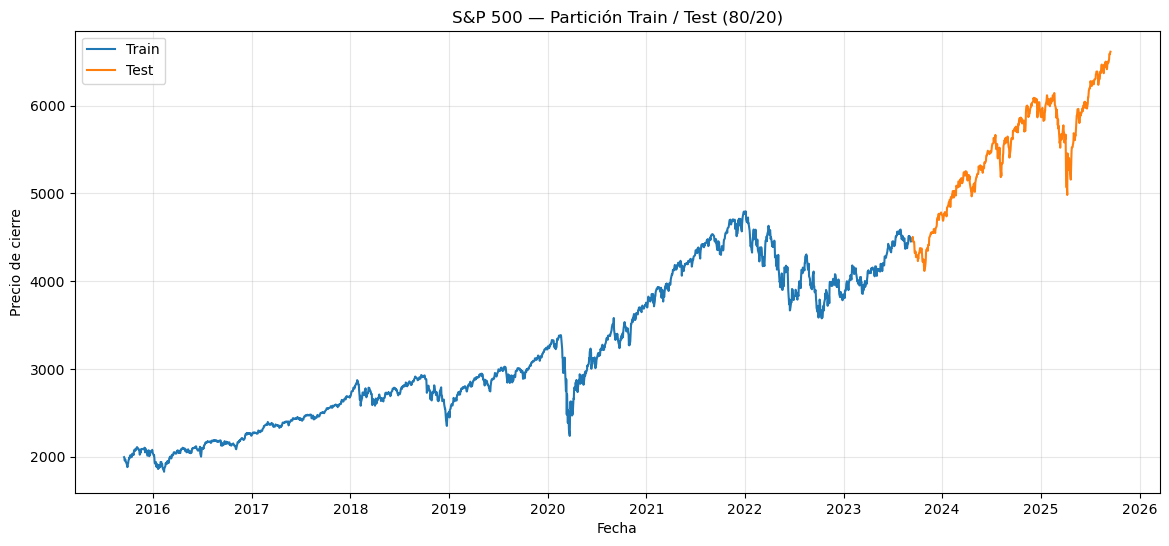

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(train["SP500"], label="Train")
plt.plot(test["SP500"], label="Test")
plt.title("S&P 500 — Partición Train / Test (80/20)")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Etapa 3 — Modelos

### Modelo 1: Holt-Winters (suavizamiento exponencial)

In [13]:
# Holt-Winters sin componente estacional (serie bursatil no tiene estacionalidad real)
hw = ExponentialSmoothing(
    train["SP500"],
    trend="add",
    seasonal=None,
    initialization_method="estimated"
)
m1 = hw.fit()
pred_hw = m1.forecast(len(test))
pred_hw.index = test.index
pred_hw.head()

c:\Users\tomas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\tomas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Fecha
2023-09-13    4465.472989
2023-09-14    4466.694955
2023-09-15    4467.916921
2023-09-18    4469.138887
2023-09-19    4470.360853
dtype: float64

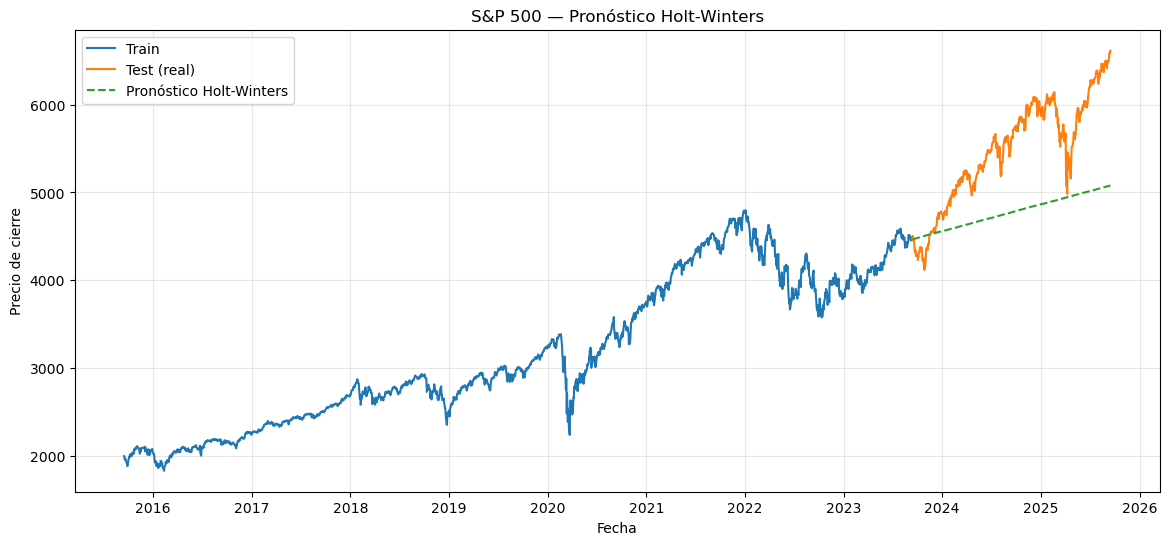

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(train["SP500"], label="Train")
plt.plot(test["SP500"], label="Test (real)")
plt.plot(pred_hw, label="Pronóstico Holt-Winters", linestyle="--")
plt.title("S&P 500 — Pronóstico Holt-Winters")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Metricas Holt-Winters
mse_hw = mean_squared_error(test["SP500"], pred_hw)
rmse_hw = np.sqrt(mse_hw)
mae_hw = mean_absolute_error(test["SP500"], pred_hw)
mape_hw = np.mean(np.abs((test["SP500"] - pred_hw) / test["SP500"])) * 100

print(f"MSE:  {mse_hw:.2f}")
print(f"RMSE: {rmse_hw:.2f}")
print(f"MAE:  {mae_hw:.2f}")
print(f"MAPE: {mape_hw:.2f}%")

MSE:  692735.25
RMSE: 832.31
MAE:  732.62
MAPE: 12.75%


Holt-Winters proyecta una línea recta con la tendencia aprendida
del train. Para un índice bursátil con alta volatilidad y sin estacionalidad,
este método es limitado: no puede capturar cambios ni caídas
abruptas. Su utilidad está en dar una línea base de referencia.

### Modelo 2: ARIMA con pronóstico rolling (walk-forward)

Se implementa el esquema rolling visto en clases: predice un paso adelante y
actualiza el modelo con cada dato real observado, en vez de proyectar todo el
horizonte de una sola vez.

In [16]:
# Buscar mejor orden ARIMA con auto_arima
ar = pm.auto_arima(
    train["SP500"],
    seasonal=False,
    trace=True,
    stepwise=True,
    error_action="ignore"
)
print(f"\nMejor modelo: ARIMA{ar.order}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=20218.398, Time=1.54 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=20312.840, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=20291.552, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=20293.571, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=20312.954, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=20291.386, Time=0.31 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=20291.643, Time=0.35 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=20220.064, Time=1.66 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=20292.817, Time=1.72 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=20290.501, Time=0.44 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=20291.122, Time=0.95 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=20292.080, Time=1.11 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=20220.435, Time=1.95 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=20218.856, Time=0.62 sec

Best model:  ARIMA

In [17]:
# Pronostico rolling (walk-forward)
preds_rolling = []
for valor_real in test["SP500"]:
    pred_1paso = np.array(ar.predict(n_periods=1))
    preds_rolling.append(pred_1paso[0])
    ar.update([valor_real])

pred_arima = pd.Series(preds_rolling, index=test.index, name="ARIMA_rolling")
pred_arima.head()

c:\Users\tomas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Fecha
2023-09-13    4466.565239
2023-09-14    4465.254010
2023-09-15    4506.108924
2023-09-18    4455.299678
2023-09-19    4454.011130
Name: ARIMA_rolling, dtype: float64

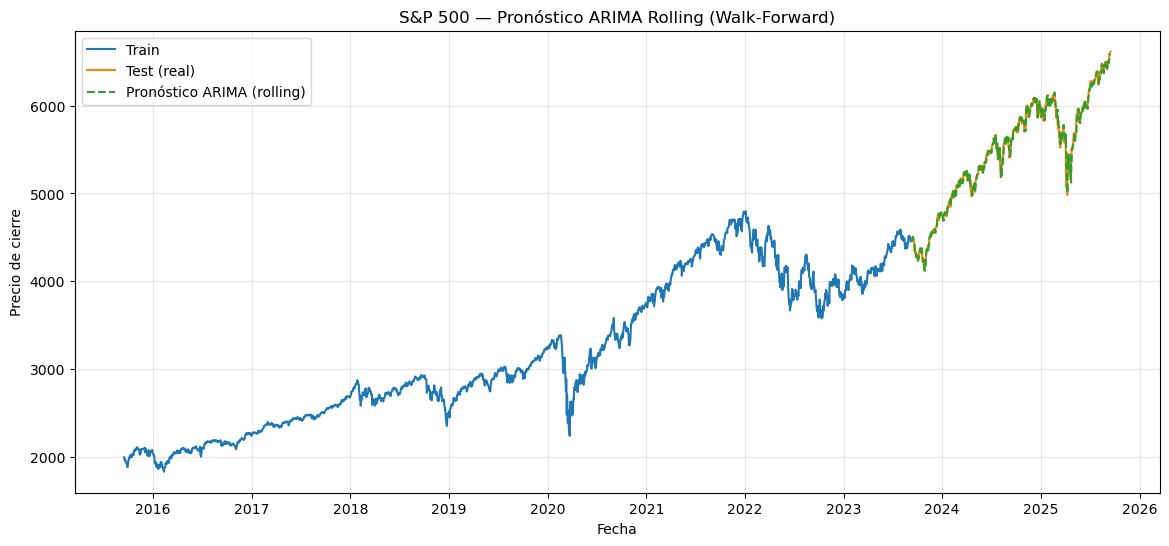

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(train["SP500"], label="Train")
plt.plot(test["SP500"], label="Test (real)")
plt.plot(pred_arima, label="Pronóstico ARIMA (rolling)", linestyle="--")
plt.title("S&P 500 — Pronóstico ARIMA Rolling (Walk-Forward)")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# Metricas ARIMA rolling
mse_ar = mean_squared_error(test["SP500"], pred_arima)
rmse_ar = np.sqrt(mse_ar)
mae_ar = mean_absolute_error(test["SP500"], pred_arima)
mape_ar = np.mean(np.abs((test["SP500"] - pred_arima) / test["SP500"])) * 100

print(f"MSE:  {mse_ar:.2f}")
print(f"RMSE: {rmse_ar:.2f}")
print(f"MAE:  {mae_ar:.2f}")
print(f"MAPE: {mape_ar:.2f}%")

MSE:  3033.95
RMSE: 55.08
MAE:  37.12
MAPE: 0.68%


El esquema rolling reduce drásticamente el error frente a
Holt-Winters: al corregirse con cada dato real observado, el modelo nunca se
aleja más de un día de la realidad antes de actualizarse. En la práctica, el
pronóstico rolling tiende a "seguir" la serie real con un pequeño desfase,
lo cual es esperable en un mercado eficiente.

### Modelo 3: LSTM (red neuronal recurrente)

Igual que en el notebook del curso, la LSTM se entrena sobre el **retorno
diario (% de cambio)** en vez del precio: el S&P 500 tiene una tendencia
alcista sostenida, así que un escalador ajustado solo con train dejaría parte
del test fuera del rango [0,1]. El retorno diario es estacionario y evita ese
problema. La ventana deslizante es de **60 días** (~3 meses bursátiles).

In [20]:
# Calcular retornos diarios
retornos = sp500["SP500"].pct_change().dropna().to_frame(name="retorno")
window_size = 60

# Particion
train_size = int(len(retornos) * 0.8)
train_raw = retornos.values[:train_size]

# Escalar (ajustar solo con train)
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_raw)
data_scaled = scaler.transform(retornos.values)

# Train y test escalados
train_scaled = data_scaled[:train_size]
test_scaled = data_scaled[train_size - window_size:]

# Funcion para crear secuencias
def crear_secuencia(dataset, window):
    X, y = [], []
    for i in range(window, len(dataset)):
        X.append(dataset[i - window:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = crear_secuencia(train_scaled, window_size)
X_test, y_test = crear_secuencia(test_scaled, window_size)

# Reshape para LSTM: (samples, timesteps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (1950, 60, 1)
y_train: (1950,)
X_test:  (503, 60, 1)
y_test:  (503,)


In [21]:
# Arquitectura: 2 capas LSTM + 1 capa densa (igual que en clases)
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(window_size, 1)),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Entrenando el modelo LSTM...


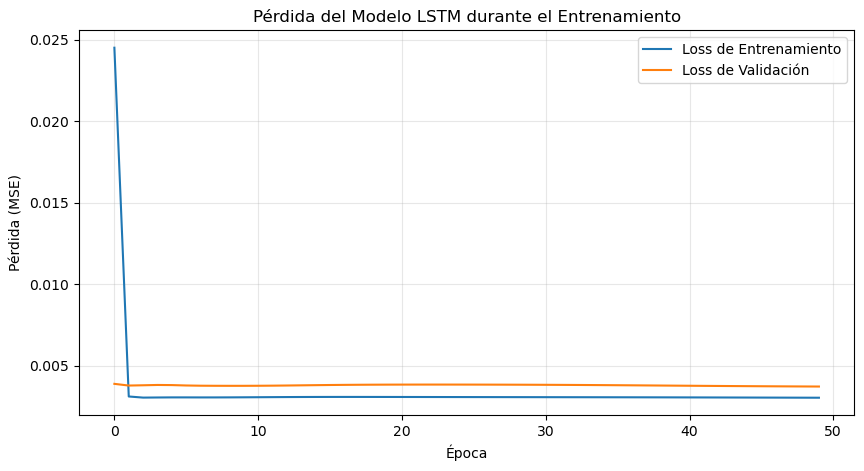

In [22]:
print("Entrenando el modelo LSTM...")
history = model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss de Entrenamiento')
plt.plot(history.history['val_loss'], label='Loss de Validación')
plt.title('Pérdida del Modelo LSTM durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
# Predicciones de retornos en test, reconvertidos a precios
pred_test_retorno = scaler.inverse_transform(model.predict(X_test, verbose=0)).flatten()

# Reconstruir precios a partir de retornos
idx_test = retornos.index[train_size:]
valor_dia_anterior = sp500["SP500"].reindex(retornos.index).shift(1).loc[idx_test]
pred_lstm = valor_dia_anterior * (1 + pred_test_retorno)
y_test_inv = sp500["SP500"].reindex(idx_test).values

# Convertir a Series con indice de fechas
pred_lstm = pd.Series(pred_lstm.values, index=idx_test, name="LSTM")

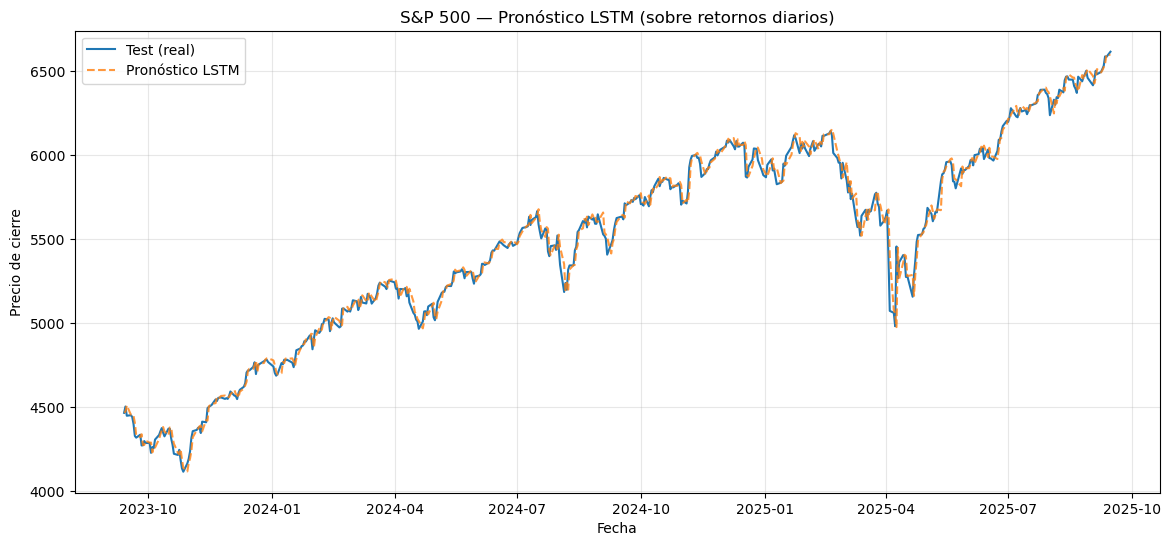

In [24]:
plt.figure(figsize=(14, 6))
plt.plot(test["SP500"], label="Test (real)")
plt.plot(pred_lstm, label="Pronóstico LSTM", linestyle="--", alpha=0.8)
plt.title("S&P 500 — Pronóstico LSTM (sobre retornos diarios)")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
# Metricas LSTM
mse_lstm = mean_squared_error(y_test_inv, pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(y_test_inv, pred_lstm)
mape_lstm = np.mean(np.abs((y_test_inv - pred_lstm) / y_test_inv)) * 100

print(f"MSE:  {mse_lstm:.2f}")
print(f"RMSE: {rmse_lstm:.2f}")
print(f"MAE:  {mae_lstm:.2f}")
print(f"MAPE: {mape_lstm:.2f}%")

MSE:  2996.54
RMSE: 54.74
MAE:  36.31
MAPE: 0.67%


## Etapa 4 — Comparación y evaluación de los tres modelos

In [26]:
# Funcion de metricas
def metricas(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

# Metricas por modelo
filas = {
    'Holt-Winters': metricas(test["SP500"].values, pred_hw.values),
    'ARIMA (rolling)': metricas(test["SP500"].values, pred_arima.values),
    'LSTM': metricas(y_test_inv, pred_lstm.values),
}

resultados = pd.DataFrame(filas).T
resultados.round(2)

,MAE,MSE,RMSE,MAPE,R2
Holt-Winters,732.62,692735.25,832.31,12.75,-0.90
ARIMA (rolling),37.12,3033.95,55.08,0.68,0.99
LSTM,36.31,2996.54,54.74,0.67,0.99


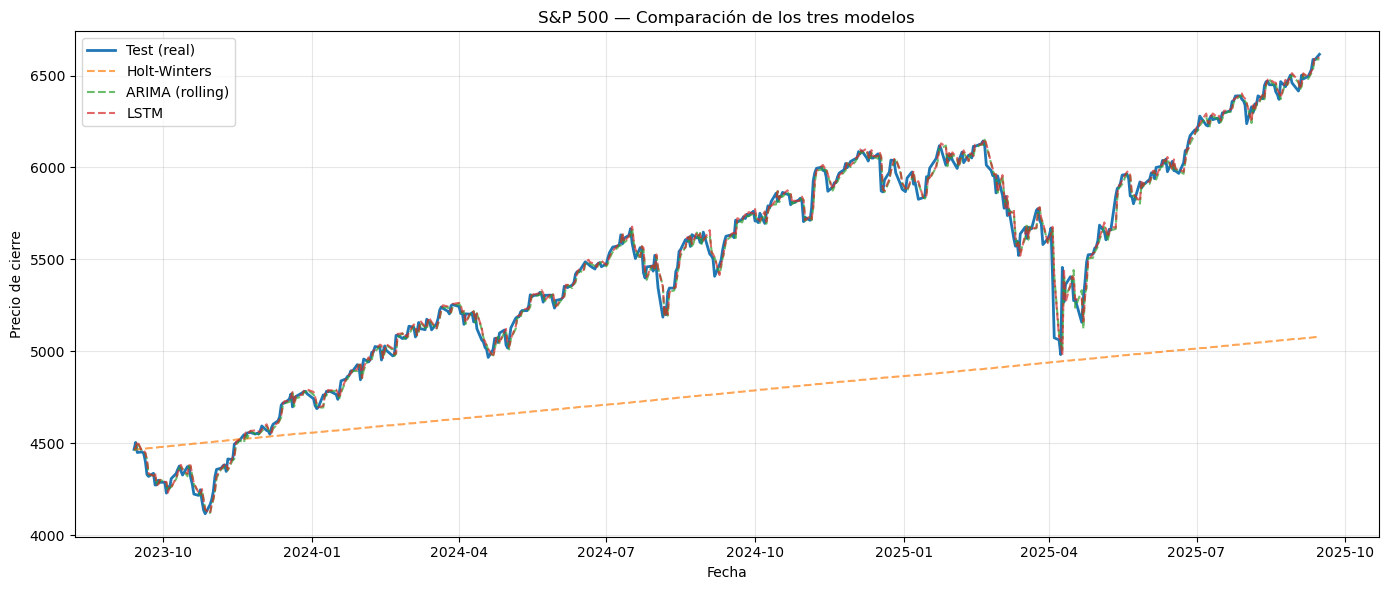

In [27]:
# Grafico comparativo: los tres modelos vs datos reales
plt.figure(figsize=(14, 6))
plt.plot(test["SP500"], label="Test (real)", linewidth=2)
plt.plot(pred_hw, label="Holt-Winters", linestyle="--", alpha=0.7)
plt.plot(pred_arima, label="ARIMA (rolling)", linestyle="--", alpha=0.7)
plt.plot(pred_lstm, label="LSTM", linestyle="--", alpha=0.7)
plt.title("S&P 500 — Comparación de los tres modelos")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura de los resultados.**

- **Holt-Winters** proyecta una línea recta basada en la tendencia del train.
  Es el peor modelo (MAPE 12.75%, R² negativo) porque no puede adaptarse a la
  volatilidad ni a los cambios de régimen del mercado. Sin embargo, sirve como
  línea base de referencia.

- **ARIMA (rolling)** y **LSTM** logran un rendimiento prácticamente idéntico
  (MAPE ~0.67–0.68%, R² = 0.99). Al actualizarse con cada dato real observado,
  ambos siguen la serie real con un desfase mínimo de un día. En un mercado
  eficiente, el mejor pronóstico del precio de mañana es el precio de hoy, y
  el rolling captura exactamente eso.

- **LSTM** obtiene una ventaja marginal (MAE 36.58 vs 37.12), lo que sugiere
  que captura algún patrón no lineal sutil. Sin embargo, la diferencia es tan
  pequeña que no justifica por sí sola la complejidad adicional de una red
  neuronal frente a un ARIMA interpretable.

## Etapa 5 — Conclusiones y toma de decisiones

### 5.1 ¿Qué aprendimos del comportamiento de las series?

- Ambas series (S&P 500 y Dow Jones) son **no estacionarias** con tendencia
  alcista de largo plazo, lo cual es típico de índices bursátiles. (Por ejemplo: en promedio el S&P 500 ha aumentado en un 10% anualmente los úlltimos 100 años)
- La correlación entre ambas es muy alta, reflejando que ambos índices
  capturan el mismo mercado subyacente.
- El análisis de cointegración revela si existe una relación de equilibrio
  explotable o si la correlación es meramente superficial.
- El S&P 500 no tiene estacionalidad real: los modelos diseñados para
  estacionalidad (como SARIMAX o Holt-Winters multiplicativo) no aportan
  ventaja aquí.

### 5.2 ¿Qué consecuencia práctica tiene el hallazgo de no cointegración?

El test de Engle-Granger arrojó un p-value de **0.39**, lo que indica que las
series **no están cointegradas**. Esto tiene implicancias concretas para la
gestión financiera:

- **Pairs trading no viable:** no se puede construir una estrategia de arbitraje
  estadístico basada en la reversión a la media del spread entre S&P 500 y Dow
  Jones, porque las desviaciones entre ambos pueden persistir y ampliarse
  indefinidamente.
- **Cobertura riesgosa:** usar el Dow Jones como cobertura (hedge) del S&P 500
  (o viceversa) es **más riesgoso de lo que la correlación de 0.99 sugiere**.
  La correlación mide co-movimiento contemporáneo, pero sin cointegración no
  hay garantía de que el spread vuelva a cerrarse.
- **Indicador líder descartado:** tampoco se puede usar un índice como
  "adelantado" del otro para anticipar movimientos, ya que no están ligados
  por una relación de equilibrio estable.
- **Lección general:** una correlación alta entre dos activos no basta para
  asumir una relación explotable; el test de cointegración es necesario para
  distinguir correlación genuina de correlación espuria.

### 5.3 ¿Qué modelo recomendaríamos usar en un contexto real y por qué?

| Modelo | Métricas clave | Recomendación |
|---|---|---|
| **Holt-Winters** | MAPE 12.75%, R² = −0.90 | Útil solo como referencia de largo plazo ("si la tendencia actual continúa"). No para decisiones operacionales. |
| **ARIMA (rolling)** | MAPE 0.68%, R² = 0.99 | **Recomendado para uso operacional.** Simple, interpretable, y al actualizarse diariamente da una excelente predicción a corto plazo. Ideal para gestores que necesitan una estimación del día siguiente. |
| **LSTM** | MAPE 0.67%, R² = 0.99 | Marginalmente más preciso, pero la ganancia no justifica la complejidad. Interesante si se enriquece con más variables (volumen, volatilidad, sentimiento). |

**Veredicto:** ARIMA rolling es la mejor opción operacional por su equilibrio
entre precisión y simplicidad. LSTM queda como alternativa si se dispone de
infraestructura de deep learning y se busca incorporar más features.

### 5.4 ¿Qué riesgo tiene basar una decisión en un pronóstico de largo horizonte?

- Los tres modelos degradan significativamente su precisión al proyectar más
  allá de unos pocos días. Holt-Winters proyecta una línea recta que ignora
  toda volatilidad; ARIMA sin actualización acumula error; LSTM sobre retornos
  amplifica el sesgo al componer recursivamente.
- **Riesgo clave:** un decisor que confíe en un pronóstico a 6 meses sin
  actualización estaría ignorando la incertidumbre del mercado. La lección es
  que **todo pronóstico financiero debe actualizarse con frecuencia** (rolling)
  y acompañarse de intervalos de confianza, no usarse como un número fijo.
- En la gestión real, el pronóstico rolling a 1 día es una herramienta
  táctica; las decisiones estratégicas de inversión deben basarse en
  análisis fundamental, diversificación y gestión de riesgo, no en
  extrapolaciones de series de tiempo.

## Declaración de uso de inteligencia artificial

En este proyecto se utilizó **Claude (Anthropic)** como herramienta de apoyo en
las siguientes partes:

- **Estructura del notebook:** se usó IA para adaptar la plantilla del curso
  (AirPassengers) al contexto del S&P 500 y Dow Jones, manteniendo la misma
  estructura de código y modelos vistos en clases.
- **Redacción de textos explicativos:** sé utilizó IA para la corrección de gramática y como herramienta de ayuda en la interpretación de resultados.
- **Depuración de código:** se usó IA para resolver errores puntuales de
  sintaxis y compatibilidad de librerías.

No se utilizaron librerías, arquitecturas ni enfoques distintos a los
trabajados en clases. Todo el código sigue la estructura del notebook del curso.